In [7]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statsmodels.formula.api as smf
import statsmodels.api as sm
from pathlib import Path
from scipy import stats

Saved → /home/qmoreau/gogo_bursts/stat_output/PC_12_STIM_burst_LONGtoSHORT_trend_over_time_all_tertiles.pdf


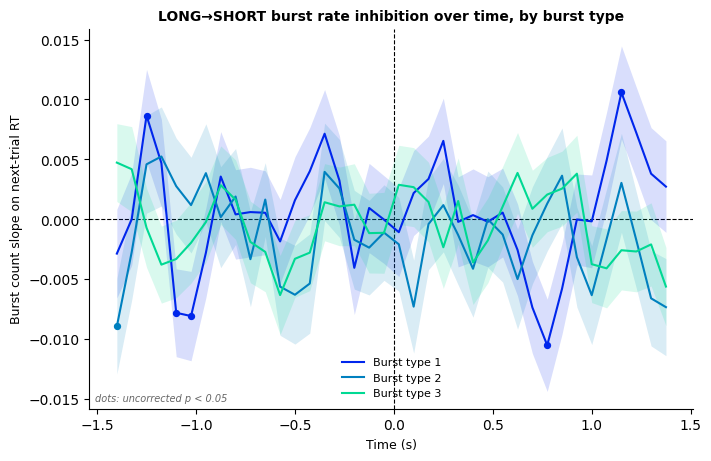

In [9]:
import numpy as np

# ── normalize trend columns: works for both the original and emtrends output ──
def normalize_trends(tr):
    tr = tr.rename(columns={
        "p.value": "p_value",
        "burst_count_long.trend": "estimate",
        "asymp.LCL": "lcl",
        "asymp.UCL": "ucl",
    })
    if "age_c" in tr.columns:                      # emtrends: 3 rows per timepoint
        tr = tr[np.isclose(tr["age_c"], 0.0)]      # keep the mid-age slope only
    return tr

trends_p = normalize_trends(trends.copy())

# fail loudly rather than plotting nonsense
for t in TERTILES:
    sub = trends_p[trends_p["tertile"] == t]
    if len(sub) and sub["time"].duplicated().any():
        raise ValueError(
            f"T{t}: {len(sub)} rows for {sub['time'].nunique()} timepoints — "
            "trend file still has >1 row per time; check the grouping column."
        )

has_p = "p_value" in trends_p.columns

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5), constrained_layout=True)
ax.axhline(0, color="k", linestyle="--", linewidth=0.8, zorder=1)
ax.axvline(0, color="k", linestyle="--", linewidth=0.8, zorder=1)

for t in TERTILES:
    color = BURST_COLORS[t]
    trends_t = trends_p[trends_p["tertile"] == t].sort_values("time")
    if trends_t.empty:
        print(f"  [no trend data for T{t}]")
        continue

    ax.fill_between(
        trends_t["time"],
        trends_t["estimate"] - trends_t["SE"],
        trends_t["estimate"] + trends_t["SE"],
        color=color, alpha=0.15, linewidth=0,
    )
    ax.plot(trends_t["time"], trends_t["estimate"],
            color=color, linewidth=1.5, label=BURST_LABELS[t])

    if has_p:
        sig = trends_t[trends_t["p_value"] < 0.05]
        ax.scatter(sig["time"], sig["estimate"], color=color, s=18, zorder=5)

ax.set_title("LONG→SHORT burst rate inhibition over time, by burst type",
             fontweight="bold", fontsize=10)
ax.set_xlabel("Time (s)", fontsize=9)
ax.set_ylabel("Burst count slope on next-trial RT", fontsize=9)
ax.legend(fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

if has_p:
    ax.text(0.01, 0.02, "dots: uncorrected p < 0.05", transform=ax.transAxes,
            fontsize=7, style="italic", color="0.4")

out_path = data_dir / f"PC_{pc}_{epoch}_burst_LONGtoSHORT_trend_over_time_all_tertiles.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved → {out_path}")
plt.show()

In [11]:
raw   = pd.read_csv(data_dir / f"PC_{pc}_{epoch}_trial_burst_counts.csv")
tcols = [c for c in raw.columns if c.startswith("time_")]
vals  = raw[tcols].to_numpy(dtype=float)

print(f"{len(tcols)} time columns, {vals.shape[0]} rows")
print("mean burst count per timepoint:", np.nanmean(vals))
print("proportion exactly zero:", np.mean(vals == 0))
print(pd.Series(vals.ravel()).value_counts().head())

113 time columns, 15897 rows
mean burst count per timepoint: 1.8767580681165978
proportion exactly zero: 0.2746285406997814
0.0    493332
1.0    431844
2.0    332331
3.0    224808
4.0    139963
Name: count, dtype: int64
